In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import dask.array as da
import os
from pycontrails.core import GeoVectorDataset
from pycontrails.models.gpat.gpat import GPAT, create_jobs_df, filter_jobs_df, load_fl_df, load_pl_df, load_chem_ds, plot_heatmap, anim_chem, mc_test, boxm_test

In [2]:
outputs_dir = f"{os.getcwd()}/outputs/"

In [3]:
# Filter criteria
criteria = {
        # "n_ac": 3,
        # "rt_fl": (pd.Timedelta(minutes=30), pd.Timedelta(hours=2)),
        # "date_created": (pd.Timestamp("2024-11-16"), pd.Timestamp("2024-11-17")),
        "job_id": "mc_v_2_1000_0_10_2_0"
    }

In [4]:
jobs_df = create_jobs_df(outputs_dir)

jobs_df


,t0_fl,rt_fl,ts_fl,ac_type,fl0_speed,fl0_heading,fl0_coords0,sep_dist,n_ac,dt_integration,...,n_slices,traj_gen,gen_met,bg_chem,ac_perf,emissions,sim_plumes,plume_to_grid,run_cc,run_boxm
job_id,,,,,,,,,,,,,,,,,,,,,
664484,2022-01-20 13:00:00,0 days 01:00:00,0 days 00:02:00,A320,100.0,45.0,"(47.1, -32.9, 12500)","(5000, 0, 0)",3,0 days 00:02:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
148451,2022-01-20 13:00:00,0 days 01:00:00,0 days 00:02:00,A320,100.0,45.0,"(0.1, 0.1, 12500)","(5000, 0, 0)",3,0 days 00:02:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
743172,2022-01-20 13:00:00,0 days 01:00:00,0 days 00:02:00,A320,100.0,45.0,"(0.1, 0.1, 12500)","(5000, 0, 0)",1,0 days 00:02:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
867851,2022-01-20 13:00:00,0 days 01:00:00,0 days 00:02:00,A320,100.0,45.0,"(0.1, 0.1, 12500)","(5000, 0, 0)",2,0 days 00:02:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mc_v_2_1000_0_10_2_0,2022-01-20 13:00:00,0 days 01:00:00,0 days 00:02:00,A320,100.0,45.0,"(47.1, -32.9, 12500)","(1000, 0, 0)",2,0 days 00:02:00,...,10.0,0.009301,0.272003,0.240219,0.03326,0.047843,0.225385,40.950298,0.000001,0.543526
166008,2022-01-20 13:00:00,0 days 01:00:00,0 days 00:02:00,A320,100.0,45.0,"(0.1, 0.1, 12500)","(5000, 0, 0)",0,0 days 00:02:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
filtered_df = filter_jobs_df(jobs_df, criteria)

job_ids = filtered_df.index.values

filtered_df


,t0_fl,rt_fl,ts_fl,ac_type,fl0_speed,fl0_heading,fl0_coords0,sep_dist,n_ac,dt_integration,...,n_slices,traj_gen,gen_met,bg_chem,ac_perf,emissions,sim_plumes,plume_to_grid,run_cc,run_boxm
job_id,,,,,,,,,,,,,,,,,,,,,
mc_v_2_1000_0_10_2_0,2022-01-20 13:00:00,0 days 01:00:00,0 days 00:02:00,A320,100.0,45.0,"(47.1, -32.9, 12500)","(1000, 0, 0)",2,0 days 00:02:00,...,10.0,0.009301,0.272003,0.240219,0.03326,0.047843,0.225385,40.950298,0.000001,0.543526


In [6]:
fl_df = load_fl_df(job_ids, outputs_dir)

fl_df

plume_time_data = GeoVectorDataset(data=fl_df.loc[fl_df["time"] == fl_df["time"].min()])



In [7]:
pl_df = load_pl_df(job_ids, outputs_dir)
pl_df.columns

pl_df

,flight_id,waypoint,fuel_flow,fuel_burn,true_airspeed,CO2,H2O,SO2,NO,NO2,...,longitude,latitude,level,width,heading,sigma_yy,sigma_zz,sin_a,cos_a,altitude
job_id,,,,,,,,,,,,,,,,,,,,,
mc_v_2_1000_0_10_2_0,0.0,0,1.039642,124.757011,100.099398,394.232154,153.451123,0.104796,1.712263,0.090119,...,-32.900000,47.100000,178.645172,81.026358,NaN,8.206588e+02,433.664232,NaN,NaN,12500.0
mc_v_2_1000_0_10_2_0,1.0,0,1.039631,124.755700,100.093336,394.228012,153.449511,0.104795,1.712236,0.090118,...,-32.890684,47.106360,178.645172,81.026206,NaN,8.206558e+02,433.657838,NaN,NaN,12500.0
mc_v_2_1000_0_10_2_0,0.0,0,1.039642,124.757011,100.099398,394.232154,153.451123,0.104796,1.712263,0.090119,...,-32.900000,47.100000,178.645172,143.604196,44.595919,2.577771e+03,554.828465,0.702102,0.712076,12500.0
mc_v_2_1000_0_10_2_0,0.0,1,1.039507,124.740886,100.027041,394.181199,153.431289,0.104782,1.711931,0.090102,...,-32.787015,47.175907,178.645172,81.024516,44.595919,8.206215e+02,433.586506,0.702102,0.712076,12500.0
mc_v_2_1000_0_10_2_0,1.0,0,1.039631,124.755700,100.093336,394.228012,153.449511,0.104795,1.712236,0.090118,...,-32.890684,47.106360,178.645172,143.603512,44.599371,2.577746e+03,554.815676,0.702145,0.712034,12500.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
mc_v_2_1000_0_10_2_0,0.0,7,1.038809,124.657109,99.664701,393.916464,153.328244,0.104712,1.710212,0.090011,...,-32.109103,47.631346,178.645172,10375.966048,44.845080,1.345758e+07,7429.002339,0.705192,0.709016,12500.0
mc_v_2_1000_0_10_2_0,1.0,6,1.038797,124.655694,99.658621,393.911992,153.326503,0.104711,1.710183,0.090010,...,-32.212773,47.561800,178.645172,10633.340937,44.848588,1.413349e+07,7553.923574,0.705236,0.708973,12500.0
mc_v_2_1000_0_10_2_0,1.0,7,1.038797,124.655694,99.658621,393.911992,153.326503,0.104711,1.710183,0.090010,...,-32.099787,47.637706,178.645172,10375.721479,44.848588,1.345695e+07,7428.622658,0.705236,0.708973,12500.0


In [8]:
chem_ds = load_chem_ds(job_ids, outputs_dir)

chem_ds = chem_ds.assign_coords(species_out=chem_ds.attrs["species_out"])

chem_ds_stacked = chem_ds.stack(
            {"cell": ["level", "longitude", "latitude"]}
        )
chem_ds_stacked = chem_ds_stacked.reset_index("cell")

max_emi_cell = chem_ds_stacked["emi"].mean(dim="time").argmax()#.item()
print(max_emi_cell)
# find cell that has max emissions averaged over time in it
cell_chem_ds = chem_ds_stacked.sel(job_id=job_ids[0], cell=max_emi_cell)
cell_chem_ds
# Select the emissions for the specified species
#emi_data = cell_chem_ds["emi"].sel(emi_species="NO")
#chem_data = cell_chem_ds["Y"].sel(species_out="O3")
#emi_data.plot()
#chem_data.plot()

# # # Convert time and emi data to pandas Series
# # ts = 0
# # time_series = pd.Series(emi_data["time"].values)
# # emi_series = pd.Series(emi_data.values)

# # # Print time and emi values side by side
# # for time, emi in zip(time_series, emi_series):
# #     ts += 1
# #     print(f"TS: {ts}, Time: {time}, EMI: {emi}")

# for s, species in enumerate(chem_ds["species"].values):
#     print(chem_ds["bg_chem"].isel(level=1,latitude=0,longitude=0, species=s).values)



<xarray.DataArray 'emi' ()> Size: 8B
array(766)


<xarray.Dataset> Size: 265kB
Dimensions:          (time: 721, species: 219, emi_species: 9,
                      photol_params: 5, photol_coeffs: 5, therm_coeffs: 5,
                      species_out: 13)
Coordinates:
    job_id           <U20 80B 'mc_v_2_1000_0_10_2_0'
  * time             (time) datetime64[ns] 6kB 2022-01-20T12:00:00 ... 2022-0...
    air_pressure     float64 8B 1.786e+04
    altitude         float64 8B 1.25e+04
  * species          (species) <U10 9kB 'O1D' 'O' 'OH' ... 'EMPOA' 'P2007'
  * emi_species      (emi_species) <U7 252B 'NO' 'NO2' 'CO' ... 'C2H2' 'BENZENE'
  * species_out      (species_out) <U4 208B 'O3' 'NO2' 'NO' ... 'HCHO' 'CH4'
    level            float64 8B 178.6
    longitude        float64 8B -32.3
    latitude         float64 8B 47.5
Dimensions without coordinates: photol_params, photol_coeffs, therm_coeffs
Data variables:
    air_temperature  (time) float64 6kB 219.6 219.6 219.6 ... 219.6 219.6 219.6
    H2O              (time) float64 6kB 2.255e+14 2.255e+14 ... 2.255e+14
    M                (time) float64 6kB 5.893e+18 5.893e+18 ... 5.893e+18
    O2               (time) float64 6kB 1.225e+18 1.225e+18 ... 1.225e+18
    N2               (time) float64 6kB 4.602e+18 4.602e+18 ... 4.602e+18
    sza              (time) float64 6kB 1.301 1.3 1.3 ... 1.242 1.242 1.243
    bg_chem          (species) float64 2kB 0.0 0.0 0.0 0.047 ... 0.0 0.0 0.0 0.0
    emi              (time, emi_species) float64 52kB 0.0 0.0 0.0 ... 0.0 0.0
    J                (time, photol_params) float64 29kB 1.028e-06 ... 0.01469
    DJ               (time, photol_coeffs) float64 29kB 1.028e-06 ... 0.01469
    RC               (time, therm_coeffs) float64 29kB 7.108e+03 ... 1.295e-11
    Y                (time, species_out) float64 75kB 66.04 0.047 ... 1.715e+03
Attributes:
    dts:              20.0
    species_out:      ['O3', 'NO2', 'NO', 'NO3', 'HNO3', 'PAN', 'HONO', 'HO2'...
    species_out_num:  [  6   4   8   5  14 198  13   9   3  12  11  39  21]

In [9]:
#anim_chem(job_ids[0], jobs_df, fl_df, pl_df, chem_ds, var1="Y", var2="O3", level=178.6, resample_freq="2min")

In [10]:
vecmass, gridmass, mc = mc_test(job_ids[0], jobs_df, fl_df, pl_df, chem_ds)
mc

,NO,NO2,CO,HCHO,CH3CHO,C2H4,C3H6,C2H2,BENZENE
2022-01-20 13:00:00,0.000000,0,0,0,0,0,0,0,0
2022-01-20 13:02:00,95.561199,0,0,0,0,0,0,0,0
2022-01-20 13:04:00,95.110194,0,0,0,0,0,0,0,0
2022-01-20 13:06:00,96.495869,0,0,0,0,0,0,0,0
2022-01-20 13:08:00,93.791636,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...
2022-01-20 15:02:00,99.911490,0,0,0,0,0,0,0,0
2022-01-20 15:04:00,99.935126,0,0,0,0,0,0,0,0
2022-01-20 15:06:00,99.948735,0,0,0,0,0,0,0,0
2022-01-20 15:08:00,99.987035,0,0,0,0,0,0,0,0


  0.000000000000000E+000


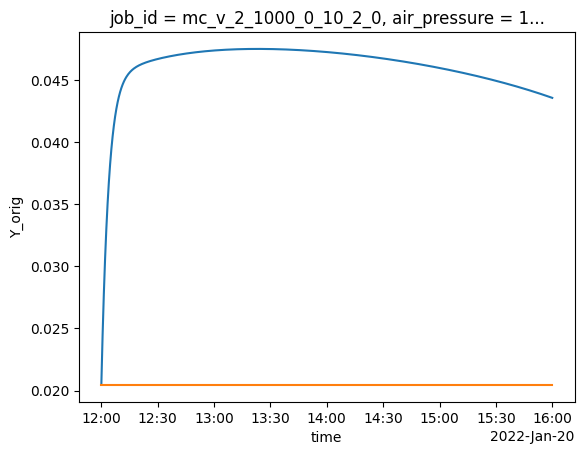

In [ ]:
path = '/home/ktait98/pycontrails_kt/pycontrails/models/gpat/'

cell_chem_ds = boxm_test(path, job_ids[0], 0, chem_ds)

# dj_data = cell_chem_ds["DJ"].sel(photol_coeffs=3)
# dj_orig_data = cell_chem_ds["DJ_orig"].sel(photol_coeffs=3)
# dj_data.plot()
# dj_orig_data.plot()

chem_data = cell_chem_ds["Y"].sel(species_out="NO")
chem_orig_data = cell_chem_ds["Y_orig"].sel(species_out="NO")
chem_data.plot()
chem_orig_data.plot()
